In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import optuna
from scipy.optimize import minimize

optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42

In [227]:
# Data
x_train = pd.read_csv("../data/x_train_final.csv")
y_train = pd.read_csv("../data/y_train_final.csv")
x_test = pd.read_csv("../data/x_test_final.csv")

In [228]:
x_train

,Unnamed: 0.1,Unnamed: 0,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
0,0,0,VBXNMF,KYF,2023-04-03,8,0.0,0.0,1.0,-3.0,-1.0,-2.0
1,1,1,VBXNMF,JLR,2023-04-03,9,0.0,0.0,0.0,1.0,0.0,1.0
2,2,2,VBXNMF,EOH,2023-04-03,10,-1.0,0.0,0.0,-1.0,0.0,0.0
3,3,3,VBXNMF,VXY,2023-04-03,11,-1.0,-1.0,0.0,2.0,-2.0,0.0
4,4,4,VBXNMF,OCB,2023-04-03,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
667259,667259,667259,BFNJJK,DGG,2023-11-10,22,0.0,-1.0,-6.0,-1.0,0.0,-2.0
667260,667260,667260,BFNJJK,KDN,2023-11-10,23,0.0,0.0,-1.0,1.0,0.0,0.0
667261,667261,667261,BFNJJK,TVD,2023-11-10,24,1.0,0.0,0.0,-1.0,-3.0,-1.0
667262,667262,667262,BFNJJK,TXP,2023-11-10,26,2.0,2.0,1.0,0.0,0.0,1.0


In [229]:
y_train

,Unnamed: 0,p0q0
0,0,-1.0
1,1,-1.0
2,2,-1.0
3,3,1.0
4,4,3.0
...,...,...
667259,667259,1.0
667260,667260,2.0
667261,667261,2.0
667262,667262,1.0


## Feature Engineering

In [ ]:
def fit_features(train_df: pd.DataFrame, y: pd.Series) -> dict:
    df = train_df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df["p0q0"] = y.values

    cols_retard = ["p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4"]
    m = 30  # smoothing bayesien
    global_mean = y.mean()

    # Frequency encoding gare
    freq_gare = df["gare"].value_counts(normalize=True)

    # Target encoding gare (bayesien)
    counts_gare = df.groupby("gare")["p0q0"].count()
    means_gare = df.groupby("gare")["p0q0"].mean()
    te_gare = (counts_gare * means_gare + m * global_mean) / (counts_gare + m)

    # Target encoding gare_arret (bayesien)
    df["gare_arret"] = df["gare"] + "_" + df["arret"].astype(str)
    counts_ga = df.groupby("gare_arret")["p0q0"].count()
    means_ga = df.groupby("gare_arret")["p0q0"].mean()
    te_gare_arret = (counts_ga * means_ga + m * global_mean) / (counts_ga + m)

    # Target encoding arret (bayesien)
    counts_arret = df.groupby("arret")["p0q0"].count()
    means_arret = df.groupby("arret")["p0q0"].mean()
    te_arret = (counts_arret * means_arret + m * global_mean) / (counts_arret + m)

    mappings = {
        "freq_gare": freq_gare,
        "te_gare": te_gare,
        "te_gare_arret": te_gare_arret,
        "te_arret": te_arret,
        "global_mean": global_mean,
    }
    return mappings


def transform_features(df: pd.DataFrame, mappings: dict) -> pd.DataFrame:
    df = df.copy()

    cols_retard = ["p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4"]

    # --- Outliers (une seule fois) ---
    df.loc[df["p0q3"] <= -500, "p0q3"] = (df["p0q2"] + df["p0q4"]) / 2
    df.loc[df["p0q4"] <= -500, "p0q4"] = (df["p0q2"] + df["p0q3"]) / 2

    # --- Date : entiers bruts (pas de sin/cos pour les arbres) ---
    df["date"] = pd.to_datetime(df["date"])
    df["month"] = df["date"].dt.month
    df["day_of_week"] = df["date"].dt.dayofweek

    # --- Encodages ---
    df["encoded_gare"] = df["gare"].map(mappings["freq_gare"]).fillna(0)
    df["te_gare"] = df["gare"].map(mappings["te_gare"]).fillna(mappings["global_mean"])

    df["gare_arret"] = df["gare"] + "_" + df["arret"].astype(str)
    df["te_gare_arret"] = df["gare_arret"].map(mappings["te_gare_arret"]).fillna(mappings["global_mean"])

    df["te_arret"] = df["arret"].map(mappings["te_arret"]).fillna(mappings["global_mean"])

    # --- Features agregees (existantes) ---
    df["somme_retard_prev_trains"] = df["p2q0"] + df["p3q0"] + df["p4q0"]
    df["somme_retard_prev_gares"] = df["p0q2"] + df["p0q3"] + df["p0q4"]

    df["nb_arrets"] = df.groupby(["train", "date"])["arret"].transform("count")

    df["diff_retard_trains"] = df["p2q0"] - df["p4q0"]
    df["diff_retard_gares"] = df["p0q2"] - df["p0q4"]
    df["max_retard"] = df[cols_retard].max(axis=1)
    df["min_retard"] = df[cols_retard].min(axis=1)
    df["std_retard"] = df[cols_retard].std(axis=1)
    df["mean_retard"] = df[cols_retard].mean(axis=1)

    # --- NOUVELLES FEATURES ---

    # Features ponderees (les retards proches comptent plus)
    df["weighted_train_delay"] = 3 * df["p2q0"] + 2 * df["p3q0"] + df["p4q0"]
    df["weighted_gare_delay"] = 3 * df["p0q2"] + 2 * df["p0q3"] + df["p0q4"]

    # Signe et magnitude
    df["sign_p0q2"] = np.sign(df["p0q2"])
    df["sign_p2q0"] = np.sign(df["p2q0"])
    df["abs_max_retard"] = df[cols_retard].abs().max(axis=1)

    # Interactions
    df["train_gare_agree"] = (np.sign(df["p2q0"]) == np.sign(df["p0q2"])).astype(int)
    signs = np.sign(df[cols_retard])
    df["nb_negatifs"] = (signs < 0).sum(axis=1)
    df["nb_positifs"] = (signs > 0).sum(axis=1)

    df = df.sort_values("date")

    # Drop colonnes inutiles
    cols_to_drop = ["Unnamed: 0.1", "Unnamed: 0", "date", "gare", "train", "gare_arret"]
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    return df


def index_reset(y_train: pd.DataFrame, df: pd.DataFrame) -> pd.DataFrame:
    y_train = y_train.loc[df.index]
    y_train = y_train.reset_index(drop=True)
    df = df.reset_index(drop=True)
    return df, y_train

In [ ]:
# Fit sur train (avec y pour target encoding), transform sur train et test
y_series = y_train.drop(columns=["Unnamed: 0"])["p0q0"]
mappings = fit_features(x_train, y_series)
x_train_fe = transform_features(x_train, mappings)
x_test_fe = transform_features(x_test, mappings)

In [232]:
x_train_fe , y_train = index_reset(y_train,x_train_fe)

In [233]:
x_train_fe

,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,month_sin,month_cos,day_of_week_sin,...,somme_retard_prev_trains,somme_retard_prev_gares,retard_moyen_gare,nb_arrets,diff_retard_trains,diff_retard_gares,max_retard,min_retard,std_retard,mean_retard
0,8,0.0,0.0,1.0,-3.0,-1.0,-2.0,0.866025,-0.500000,0.000000,...,1.0,-6.0,-0.566903,5,-1.0,-1.0,1.0,-3.0,1.471960,-0.833333
1,21,0.0,-1.0,0.0,0.0,1.0,0.0,0.866025,-0.500000,0.000000,...,-1.0,1.0,-0.457640,21,0.0,0.0,1.0,-1.0,0.632456,0.000000
2,20,-1.0,0.0,-1.0,1.0,0.0,1.0,0.866025,-0.500000,0.000000,...,-2.0,2.0,-0.388098,21,0.0,0.0,1.0,-1.0,0.894427,0.000000
3,19,0.0,-1.0,-1.0,0.0,1.0,0.0,0.866025,-0.500000,0.000000,...,-2.0,1.0,-0.137773,21,1.0,0.0,1.0,-1.0,0.752773,-0.166667
4,18,-1.0,-1.0,1.0,-2.0,0.0,0.0,0.866025,-0.500000,0.000000,...,-1.0,-2.0,-0.576181,21,-2.0,-2.0,1.0,-2.0,1.048809,-0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667259,11,2.0,3.0,0.0,1.0,0.0,2.0,-0.500000,0.866025,-0.951057,...,5.0,3.0,-0.086807,22,2.0,-1.0,3.0,0.0,1.211060,1.333333
667260,10,3.0,0.0,0.0,1.0,0.0,1.0,-0.500000,0.866025,-0.951057,...,3.0,2.0,0.264986,22,3.0,0.0,3.0,0.0,1.169045,0.833333
667261,9,0.0,0.0,-1.0,0.0,2.0,1.0,-0.500000,0.866025,-0.951057,...,-1.0,3.0,0.294527,22,1.0,-1.0,2.0,-1.0,1.032796,0.333333
667262,20,-1.0,0.0,-1.0,-2.0,-1.0,-1.0,-0.500000,0.866025,-0.951057,...,-2.0,-4.0,-0.805236,22,0.0,-1.0,0.0,-2.0,0.632456,-1.000000


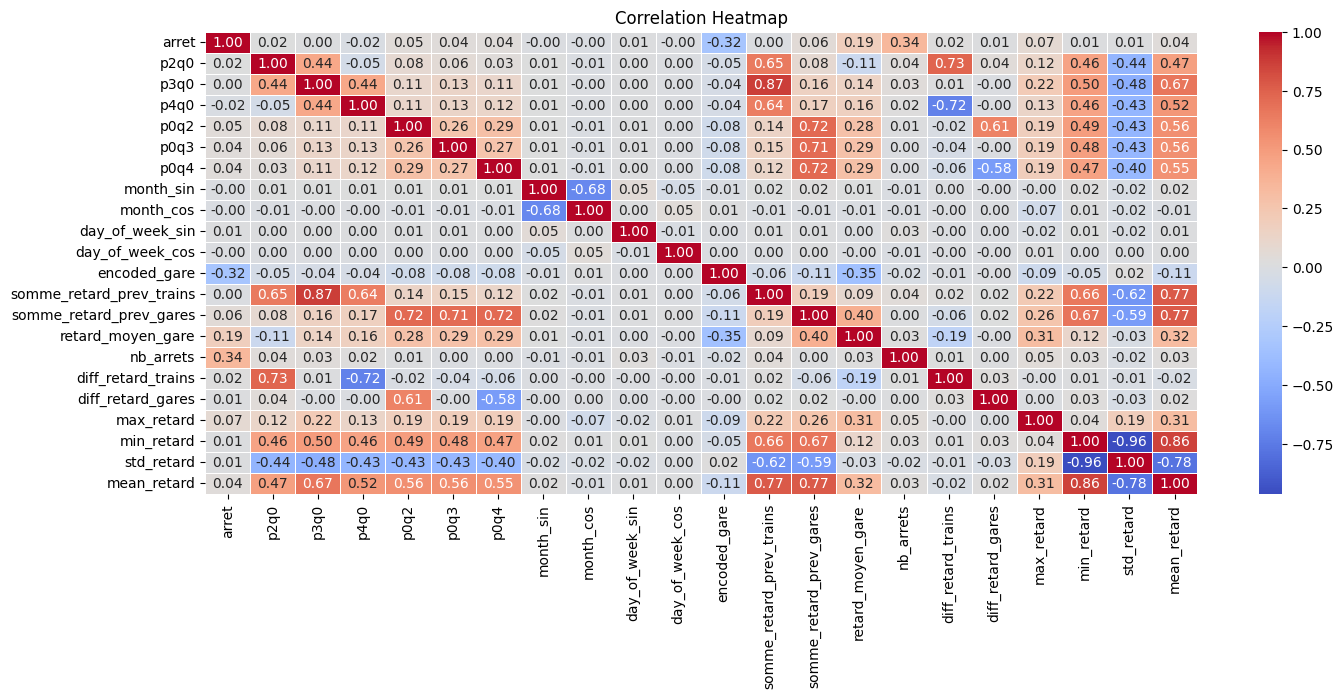

In [234]:
matrix = x_train_fe.corr()
plt.figure(figsize=(16,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [235]:
x_test_fe

,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,month_sin,month_cos,day_of_week_sin,...,somme_retard_prev_trains,somme_retard_prev_gares,retard_moyen_gare,nb_arrets,diff_retard_trains,diff_retard_gares,max_retard,min_retard,std_retard,mean_retard
0,12,0.0,0.0,-2.0,-4.0,-2.0,-4.0,-5.000000e-01,0.866025,0.000000,...,-2.0,-10.0,-0.453583,1,2.0,0.0,0.0,-4.0,1.788854,-2.000000
836,18,0.0,1.0,0.0,-1.0,-2.0,-1.0,-5.000000e-01,0.866025,0.000000,...,1.0,-4.0,-0.576181,3,0.0,0.0,1.0,-2.0,1.048809,-0.500000
835,12,0.0,0.0,0.0,0.0,2.0,0.0,-5.000000e-01,0.866025,0.000000,...,0.0,2.0,-0.109150,3,0.0,0.0,2.0,0.0,0.816497,0.333333
834,24,0.0,1.0,1.0,0.0,2.0,3.0,-5.000000e-01,0.866025,0.000000,...,2.0,5.0,0.294527,3,-1.0,-3.0,3.0,0.0,1.169045,1.166667
833,18,0.0,1.0,0.0,-1.0,-1.0,-1.0,-5.000000e-01,0.866025,0.000000,...,1.0,-3.0,-0.576181,3,0.0,0.0,1.0,-1.0,0.816497,-0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20623,12,1.0,-1.0,1.0,0.0,0.0,0.0,-2.449294e-16,1.000000,-0.951057,...,1.0,0.0,-0.195711,2,0.0,0.0,1.0,-1.0,0.752773,0.166667
20624,30,-3.0,-1.0,0.0,0.0,-1.0,0.0,-2.449294e-16,1.000000,-0.951057,...,-4.0,-1.0,-0.185569,2,-3.0,0.0,0.0,-3.0,1.169045,-0.833333
20625,12,1.0,1.0,1.0,-1.0,-2.0,-2.0,-2.449294e-16,1.000000,-0.951057,...,3.0,-5.0,-0.566903,1,0.0,1.0,1.0,-2.0,1.505545,-0.333333
20613,18,-1.0,-1.0,-1.0,0.0,-2.0,-1.0,-2.449294e-16,1.000000,-0.951057,...,-3.0,-3.0,-0.398955,2,0.0,1.0,0.0,-2.0,0.632456,-1.000000


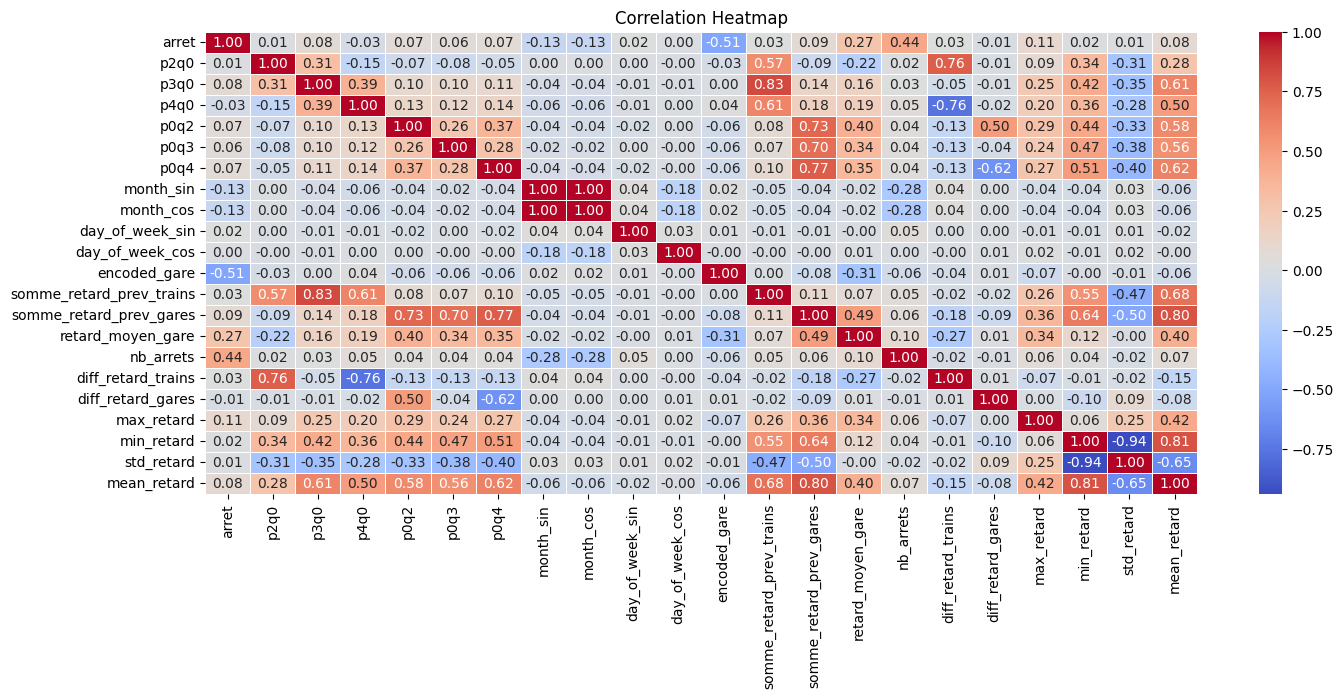

In [236]:
matrix = x_test_fe.corr()
plt.figure(figsize=(16,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Modeles

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

X = x_train_fe.values
X_test = x_test_fe.values
y = y_train.drop(columns=["Unnamed: 0"])["p0q0"].values

# --- Baseline XGBoost avec objectif MAE ---
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_scores = []

xgb_params = {
    "n_estimators": 5000,
    "learning_rate": 0.01,
    "max_depth": 8,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "reg:absoluteerror",
    "tree_method": "hist",
    "random_state": SEED,
    "eval_metric": "mae",
}

print("Baseline XGBoost (MAE objective) - TimeSeriesSplit")
print("-" * 60)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X, y), 1):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    model = xgb.XGBRegressor(**xgb_params, early_stopping_rounds=200)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred
    test_preds += model.predict(X_test) / tscv.n_splits

    score = mean_absolute_error(y_val, val_pred)
    fold_scores.append(score)
    print(f"  Fold {fold} | MAE = {score:.4f}")

print("-" * 60)
oof_score = mean_absolute_error(y[oof_preds != 0], oof_preds[oof_preds != 0])
print(f"  OOF MAE = {oof_score:.4f}")
print(f"  Moyenne  = {np.mean(fold_scores):.4f} +/- {np.std(fold_scores):.4f}")

## Optimisation Optuna

In [ ]:
# --- Optuna XGBoost ---

def objective_xgb(trial):
    params = {
        "n_estimators": 5000,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 2),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 2),
        "reg_lambda": trial.suggest_float("reg_lambda", 1, 10),
        "objective": "reg:absoluteerror",
        "tree_method": "hist",
        "random_state": SEED,
        "eval_metric": "mae",
    }

    oof_preds = np.zeros(len(X))
    for train_idx, val_idx in tscv.split(X, y):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model = xgb.XGBRegressor(**params, early_stopping_rounds=200)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        oof_preds[val_idx] = model.predict(X_val)

    return mean_absolute_error(y[oof_preds != 0], oof_preds[oof_preds != 0])

study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgb, n_trials=50)

print(f"\nXGBoost - Meilleur MAE: {study_xgb.best_value:.4f}")
print("Params:", study_xgb.best_params)

In [ ]:
# --- Optuna LightGBM ---

def objective_lgb(trial):
    params = {
        "n_estimators": 5000,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 10.0, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 2.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "objective": "mae",
        "random_state": SEED,
        "verbose": -1,
    }

    oof_preds = np.zeros(len(X))
    for train_idx, val_idx in tscv.split(X, y):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(-1)],
        )
        oof_preds[val_idx] = model.predict(X_val)

    return mean_absolute_error(y[oof_preds != 0], oof_preds[oof_preds != 0])

study_lgb = optuna.create_study(direction="minimize")
study_lgb.optimize(objective_lgb, n_trials=50)

print(f"\nLightGBM - Meilleur MAE: {study_lgb.best_value:.4f}")
print("Params:", study_lgb.best_params)

## Ensemble XGBoost + LightGBM + CatBoost

In [ ]:
# --- Entrainement final : 3 modeles avec TimeSeriesSplit ---

features = x_train_fe.columns.tolist()
print(f"Nombre de features: {len(features)}")
print(f"Features: {features}")

# 1) XGBoost avec best params
xgb_best = study_xgb.best_params.copy()
xgb_best.update({
    "n_estimators": 5000,
    "objective": "reg:absoluteerror",
    "tree_method": "hist",
    "random_state": SEED,
    "eval_metric": "mae",
})

# 2) LightGBM avec best params
lgb_best = study_lgb.best_params.copy()
lgb_best.update({
    "n_estimators": 5000,
    "objective": "mae",
    "random_state": SEED,
    "verbose": -1,
})

# 3) CatBoost
cat_params = {
    "iterations": 5000,
    "learning_rate": 0.03,
    "depth": 8,
    "l2_leaf_reg": 3,
    "random_seed": SEED,
    "loss_function": "MAE",
    "verbose": 0,
}

# --- Training avec TimeSeriesSplit ---
oof_xgb = np.zeros(len(X))
oof_lgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
test_xgb = np.zeros(len(X_test))
test_lgb = np.zeros(len(X_test))
test_cat = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(tscv.split(X, y), 1):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    # XGBoost
    m_xgb = xgb.XGBRegressor(**xgb_best, early_stopping_rounds=200)
    m_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx] = m_xgb.predict(X_val)
    test_xgb += m_xgb.predict(X_test) / tscv.n_splits

    # LightGBM
    m_lgb = lgb.LGBMRegressor(**lgb_best)
    m_lgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(-1)])
    oof_lgb[val_idx] = m_lgb.predict(X_val)
    test_lgb += m_lgb.predict(X_test) / tscv.n_splits

    # CatBoost
    m_cat = CatBoostRegressor(**cat_params)
    m_cat.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=200)
    oof_cat[val_idx] = m_cat.predict(X_val)
    test_cat += m_cat.predict(X_test) / tscv.n_splits

    mae_xgb = mean_absolute_error(y_val, oof_xgb[val_idx])
    mae_lgb = mean_absolute_error(y_val, oof_lgb[val_idx])
    mae_cat = mean_absolute_error(y_val, oof_cat[val_idx])
    print(f"Fold {fold} | XGB={mae_xgb:.4f} | LGB={mae_lgb:.4f} | CAT={mae_cat:.4f}")

# Mask pour les folds valides (OOF non zero)
mask = oof_xgb != 0
print("\n--- Scores OOF individuels ---")
print(f"XGBoost  MAE: {mean_absolute_error(y[mask], oof_xgb[mask]):.4f}")
print(f"LightGBM MAE: {mean_absolute_error(y[mask], oof_lgb[mask]):.4f}")
print(f"CatBoost MAE: {mean_absolute_error(y[mask], oof_cat[mask]):.4f}")

## Blending optimise + Post-processing

In [ ]:
# --- Optimisation des poids de blending sur OOF ---

def blend_mae(weights):
    w = np.array(weights)
    w = w / w.sum()  # normaliser
    blend = w[0] * oof_xgb[mask] + w[1] * oof_lgb[mask] + w[2] * oof_cat[mask]
    return mean_absolute_error(y[mask], blend)

result = minimize(blend_mae, x0=[1/3, 1/3, 1/3],
                  method="Nelder-Mead",
                  options={"maxiter": 10000})

w_opt = np.array(result.x)
w_opt = w_opt / w_opt.sum()
print(f"Poids optimaux: XGB={w_opt[0]:.3f}, LGB={w_opt[1]:.3f}, CAT={w_opt[2]:.3f}")

# Predictions blendees
oof_blend = w_opt[0] * oof_xgb + w_opt[1] * oof_lgb + w_opt[2] * oof_cat
test_blend = w_opt[0] * test_xgb + w_opt[1] * test_lgb + w_opt[2] * test_cat

mae_blend = mean_absolute_error(y[mask], oof_blend[mask])
print(f"MAE Blend OOF: {mae_blend:.4f}")

# --- Post-processing : arrondi + clip ---
test_final = np.clip(test_blend, -20, 15)
test_final = np.round(test_final)

# Verif sur OOF
oof_rounded = np.round(np.clip(oof_blend, -20, 15))
mae_rounded = mean_absolute_error(y[mask], oof_rounded[mask])
print(f"MAE Blend+Round OOF: {mae_rounded:.4f}")

# Comparaison
print(f"\n--- Resume ---")
print(f"XGB seul:        {mean_absolute_error(y[mask], oof_xgb[mask]):.4f}")
print(f"LGB seul:        {mean_absolute_error(y[mask], oof_lgb[mask]):.4f}")
print(f"CAT seul:        {mean_absolute_error(y[mask], oof_cat[mask]):.4f}")
print(f"Blend:           {mae_blend:.4f}")
print(f"Blend+Round:     {mae_rounded:.4f}")

In [ ]:
# --- Soumission finale ---
submission = pd.DataFrame({
    'p0q0': test_final
}, index=x_test.index)

oof_str = f"{mae_rounded:.4f}"
filename = f"../output/y_test_predictions_MAE_{oof_str}.csv"

print(f'Nombre de predictions : {len(submission)}')
print(f'Valeurs manquantes    : {submission.isnull().sum().sum()}')
print(f'Min predit            : {submission["p0q0"].min():.4f}')
print(f'Max predit            : {submission["p0q0"].max():.4f}')
print(f'Moyenne predite       : {submission["p0q0"].mean():.4f}')

submission.to_csv(filename)
print(f'\nFichier sauvegarde : {filename}')
display(submission.head(10))